In [1]:
from fno_uq.models.fno import FNO2d
from fno_uq.train import train
from neuralop.data.datasets import load_darcy_flow_small
from neuralop import H1Loss
import torch
from torch.optim import AdamW
import matplotlib.pyplot as plt
import random

In [2]:
fno = FNO2d(
    in_channels=1,
    out_channels=1,
    hidden_channels=24,
    n_modes_x=8,
    n_modes_y=8,
    n_layers=4
)

In [3]:
train_loader, test_loaders, data_processor = load_darcy_flow_small(
    n_train=1000,
    batch_size=64,
    n_tests=[100, 50],
    test_resolutions=[16, 32],
    test_batch_sizes=[32, 32],
)

Loading test db for resolution 16 with 100 samples 
Loading test db for resolution 32 with 50 samples 


In [4]:
h1loss = H1Loss(d=2)  # H1 loss includes gradient information
optimiser = AdamW(fno.parameters(), lr=1e-2, weight_decay=1e-4)
device = torch.device("cpu")

train_history = train(model=fno, train_loader=train_loader, test_loaders=test_loaders, loss_fn=h1loss, optimiser=optimiser, device=device, epochs=30)

/Users/tomstent/.virtualenvs/maths_env/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


epoch: 0, avg train loss: 47.21568559265137
epoch: 5, avg train loss: 17.145983016967772
epoch: 10, avg train loss: 12.498535514831543
epoch: 15, avg train loss: 11.250654808044434
epoch: 20, avg train loss: 11.122290336608886
epoch: 25, avg train loss: 10.254313358306884


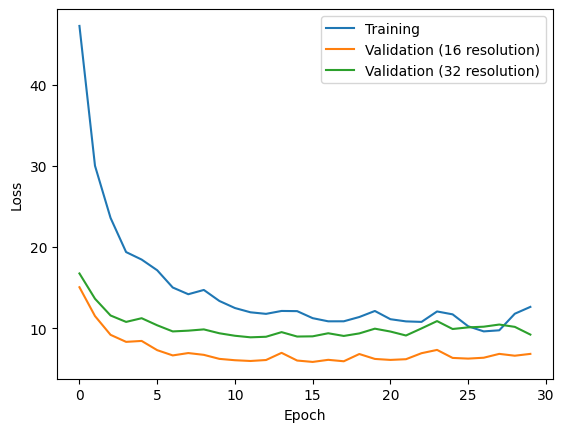

In [6]:
plt.plot(range(len(train_history["train_loss"])), train_history["train_loss"], label="Training")
plt.plot(range(len(train_history["val_loss"][16])), train_history["val_loss"][16], label="Validation (16 resolution)")
plt.plot(range(len(train_history["val_loss"][32])), train_history["val_loss"][32], label="Validation (32 resolution)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

/var/folders/1s/kw07rc7x4h38919n18zshh740000gn/T/ipykernel_4893/3202778729.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


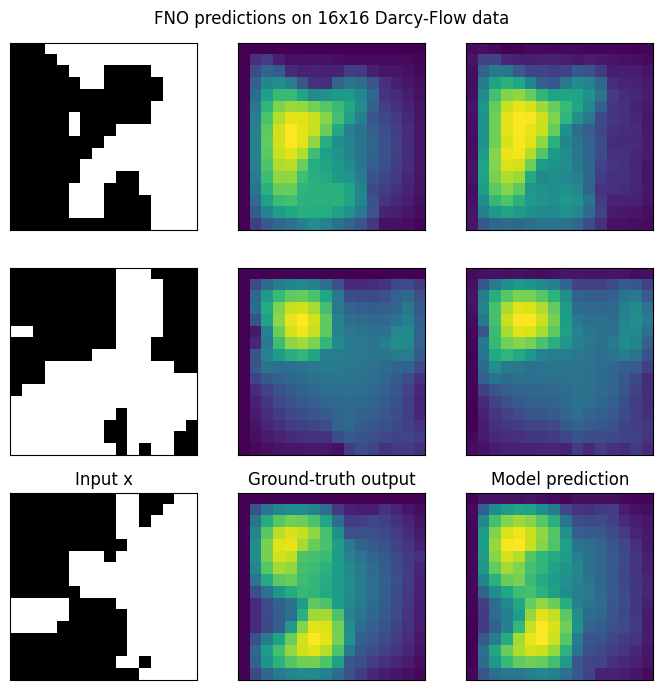

In [7]:
test_samples = test_loaders[16].dataset

indices = random.sample(range(len(test_samples)), 3)

fig = plt.figure(figsize=(7, 7))
counter=0
for index in indices:
    data = test_samples[index]

    # Input
    x = data["x"]
    # Ground-truth output
    y = data["y"]
    # Model prediction
    out = fno(x.unsqueeze(0))

    # Plot input
    ax = fig.add_subplot(3, 3, counter * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot ground-truth output
    ax = fig.add_subplot(3, 3, counter * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot model prediction
    ax = fig.add_subplot(3, 3, counter * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

    counter += 1

fig.suptitle("FNO predictions on 16x16 Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()

/var/folders/1s/kw07rc7x4h38919n18zshh740000gn/T/ipykernel_4893/4186415538.py:45: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


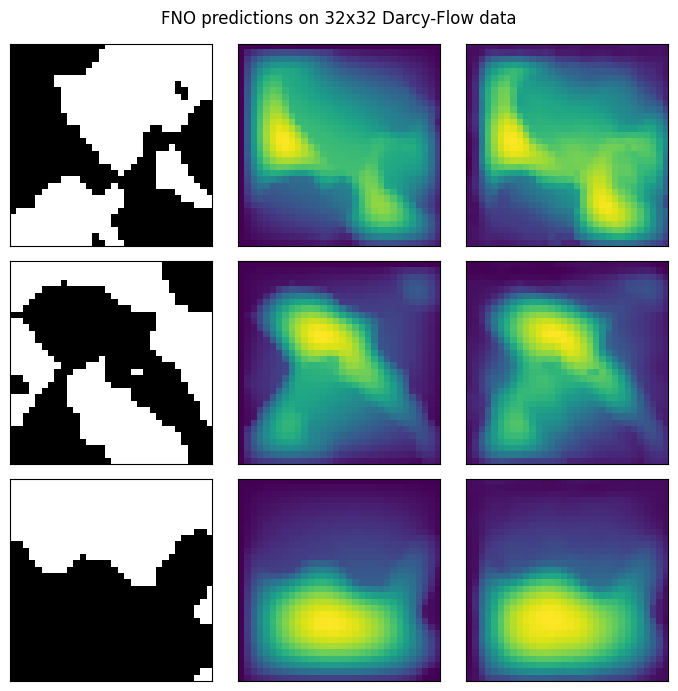

In [8]:
test_samples = test_loaders[32].dataset

indices = random.sample(range(len(test_samples)), 3)

fig = plt.figure(figsize=(7, 7))
counter=0
for index in indices:
    data = test_samples[index]

    # Input
    x = data["x"]
    # Ground-truth output
    y = data["y"]
    # Model prediction
    out = fno(x.unsqueeze(0))

    # Plot input
    ax = fig.add_subplot(3, 3, counter * 3 + 1)
    ax.imshow(x[0], cmap="gray")
    if index == 0:
        ax.set_title("Input x")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot ground-truth output
    ax = fig.add_subplot(3, 3, counter * 3 + 2)
    ax.imshow(y.squeeze())
    if index == 0:
        ax.set_title("Ground-truth output")
    plt.xticks([], [])
    plt.yticks([], [])

    # Plot model prediction
    ax = fig.add_subplot(3, 3, counter * 3 + 3)
    ax.imshow(out.squeeze().detach().numpy())
    if index == 0:
        ax.set_title("Model prediction")
    plt.xticks([], [])
    plt.yticks([], [])

    counter += 1

fig.suptitle("FNO predictions on 32x32 Darcy-Flow data", y=0.98)
plt.tight_layout()
fig.show()